# Circuits

In [104]:
import cicsim as cs
import os
home = os.getenv("HOME")
jnwatr = "pro/aicex/ip/jnw_atr_sky130a/sim"
tr_1f2 = "JNWATR_NCH_2C1F2"
tr_5f0 = "JNWATR_NCH_2C5F0"
corner = "KttTtVt"
raw = "output_dc/dc_SchGt"


path_1f2 = f"{home}/{jnwatr}/{tr_1f2}/{raw}{corner}.raw"
path_5f0 = f"{home}/{jnwatr}/{tr_5f0}/{raw}{corner}.raw"

df_1f2 = cs.toDataFrame(path_1f2)
df_5f0 = cs.toDataFrame(path_5f0)

In [105]:
print(df_1f2.columns)

Index(['v(v-sweep)', '@m.xdut.xm1.msky130_fd_pr__nfet_01v8[cgd]',
       '@m.xdut.xm1.msky130_fd_pr__nfet_01v8[cgg]',
       '@m.xdut.xm1.msky130_fd_pr__nfet_01v8[cgs]',
       '@m.xdut.xm1.msky130_fd_pr__nfet_01v8[gds]',
       '@m.xdut.xm1.msky130_fd_pr__nfet_01v8[gm]',
       'i(@m.xdut.xm1.msky130_fd_pr__nfet_01v8[id])',
       'v(@m.xdut.xm1.msky130_fd_pr__nfet_01v8[l])',
       'v(@m.xdut.xm1.msky130_fd_pr__nfet_01v8[vdsat])',
       'v(@m.xdut.xm1.msky130_fd_pr__nfet_01v8[vth])',
       'v(@m.xdut.xm1.msky130_fd_pr__nfet_01v8[w])', 'v(b)', 'v(d)', 'v(g)',
       'gds', 'gm', 'i(id)', 'v(s)', 'v(vdsat)', 'v(vth)', 'wl'],
      dtype='object')


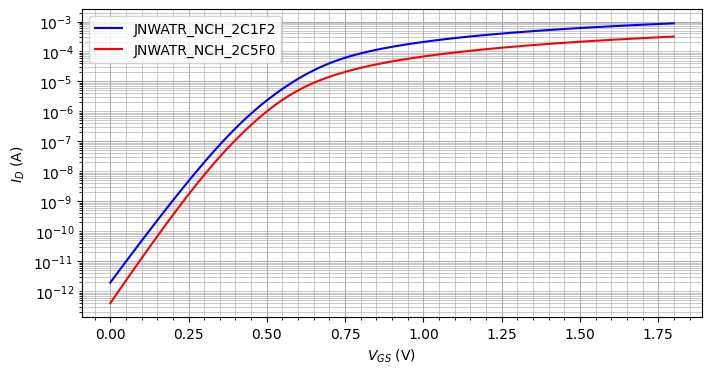

In [106]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator, AutoMinorLocator

plt.figure(figsize=(8, 4))
plt.plot(df_1f2["v(g)"], df_1f2["i(id)"], label=f"{tr_1f2}",color="blue")
plt.plot(df_5f0["v(g)"], df_5f0["i(id)"], label=f"{tr_5f0}",color="red")
plt.xlabel(r"$V_{GS}$ (V)")
plt.ylabel("$I_D$ (A)")
plt.yscale("log")
ax = plt.gca()
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1, 10) * 0.1, numticks=12))
ax.xaxis.set_minor_locator(AutoMinorLocator())
plt.grid(True, which="major")
plt.grid(True, which="minor", color="0.7", linestyle="-", linewidth=0.5)
plt.tick_params(axis="y", which="minor", left=True)
plt.tick_params(axis="x", which="minor", bottom=True)
plt.legend()
plt.savefig("../media/jnw_id_vgs.pdf")
plt.savefig("../media/jnw_id_vgs.svg")
plt.show()


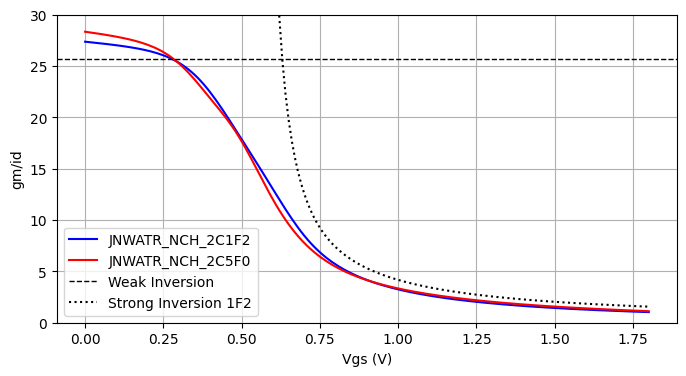

In [107]:
import matplotlib.pyplot as plt
gmid_1f2 = df_1f2["gm"]/df_1f2["i(id)"]
gmid_5f0 = df_5f0["gm"]/df_5f0["i(id)"]

gmid_weak = 1/1.5/26e-3
gmid_strong = 2/(df_1f2["v(g)"] - df_1f2["v(vth)"])

# Plot
plt.figure(figsize=(8, 4))
plt.plot(df_1f2["v(g)"], gmid_1f2, label=f"{tr_1f2}",color="blue")
plt.plot(df_5f0["v(g)"], gmid_5f0, label=f"{tr_5f0}",color="red")
plt.xlabel("Vgs (V)")
plt.ylabel("gm/id")
plt.axhline(y=gmid_weak, color="black", linewidth=1,linestyle="--",label="Weak Inversion")

#- only plot for v(g) > v(vth)
plt.plot(df_1f2["v(g)"][df_1f2["v(g)"] > df_1f2["v(vth)"]], gmid_strong[df_1f2["v(g)"] > df_1f2["v(vth)"]], label="Strong Inversion 1F2",linestyle="dotted",color="black")
plt.ylim(0,30)
plt.grid("both")
plt.legend()
plt.savefig("../media/jnw_gmid_vgs.svg")
plt.savefig("../media/jnw_gmid_vgs.pdf")
plt.show()

# Plot


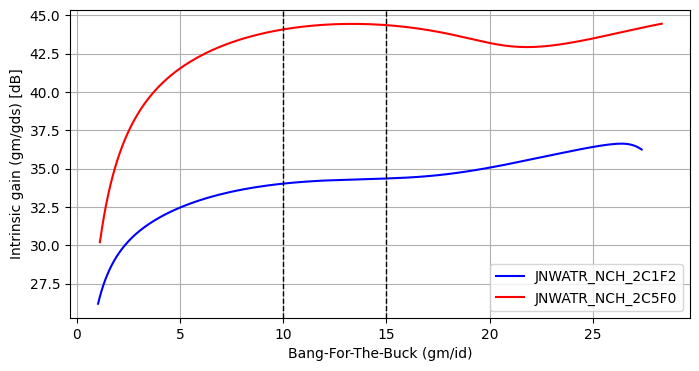

In [108]:
# Compute gm/gds for both devices
gmgds_1f2 = df_1f2["gm"] / df_1f2["gds"]
gmgds_5f0 = df_5f0["gm"] / df_5f0["gds"]

# Plot
plt.figure(figsize=(8, 4))
plt.plot(gmid_1f2, 20*np.log10(gmgds_1f2), label=f"{tr_1f2}", color="blue")
plt.plot(gmid_5f0, 20*np.log10(gmgds_5f0), label=f"{tr_5f0}", color="red")
plt.axvline(x=15, color="black", linewidth=1,linestyle="--")
plt.axvline(x=10, color="black", linewidth=1,linestyle="--")
plt.xlabel("Bang-For-The-Buck (gm/id)")
plt.ylabel("Intrinsic gain (gm/gds) [dB]")
plt.grid("both")
plt.legend()
plt.savefig("../media/jnw_gmgds_gmid.svg")
plt.savefig("../media/jnw_gmgds_gmid.pdf")
plt.show()


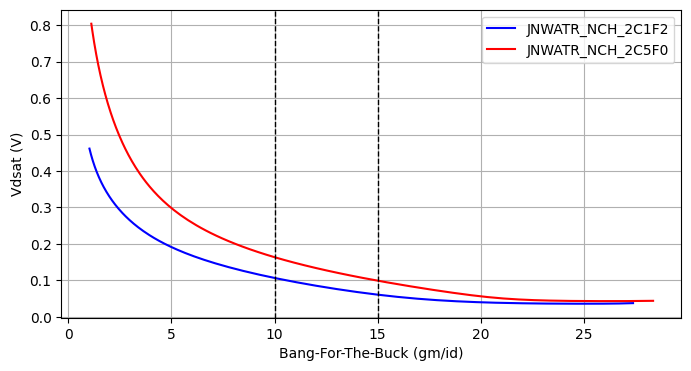

In [109]:
# Compute gm/gds for both devices

# Plot
plt.figure(figsize=(8, 4))
plt.plot(gmid_1f2, df_1f2["v(vdsat)"], label=f"{tr_1f2}", color="blue")
plt.plot(gmid_5f0, df_5f0["v(vdsat)"], label=f"{tr_5f0}", color="red")
plt.axvline(x=15, color="black", linewidth=1,linestyle="--")
plt.axvline(x=10, color="black", linewidth=1,linestyle="--")
plt.xlabel("Bang-For-The-Buck (gm/id)")
plt.ylabel("Vdsat (V)")
plt.grid("both")
plt.legend()
plt.savefig("../media/jnw_vdsat_gmid.svg")  
plt.savefig("../media/jnw_vdsat_gmid.pdf") 
plt.show()


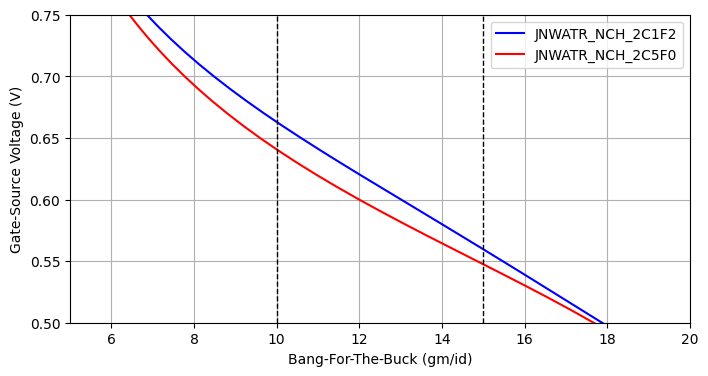

In [110]:
# Compute gm/gds for both devices

# Plot
plt.figure(figsize=(8, 4))
plt.plot(gmid_1f2, df_1f2["v(g)"], label=f"{tr_1f2}", color="blue")
plt.plot(gmid_5f0, df_5f0["v(g)"], label=f"{tr_5f0}", color="red")
plt.axvline(x=15, color="black", linewidth=1,linestyle="--")
plt.axvline(x=10, color="black", linewidth=1,linestyle="--")
plt.xlabel("Bang-For-The-Buck (gm/id)")
plt.ylabel("Gate-Source Voltage (V)")
plt.ylim(0.5,0.75)
plt.xlim(5,20)
plt.grid("both")
plt.legend()
plt.savefig("../media/jnw_vg_gmid.svg")  
plt.savefig("../media/jnw_vg_gmid.pdf") 
plt.show()


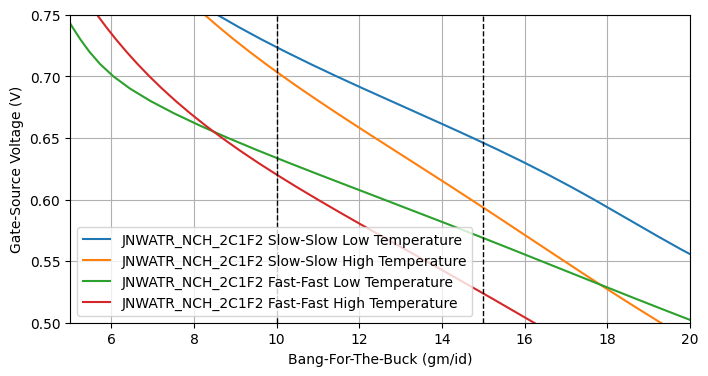

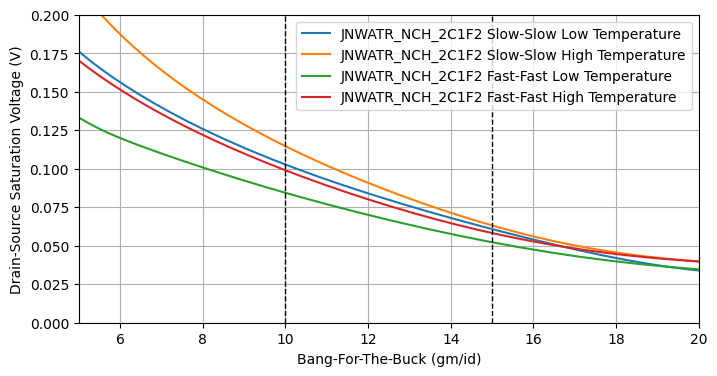

In [111]:
df_ss_tl_1f2 = cs.toDataFrame(f"{home}/{jnwatr}/{tr_1f2}/{raw}KssTlVt.raw")
df_ss_th_1f2 = cs.toDataFrame(f"{home}/{jnwatr}/{tr_1f2}/{raw}KssTahVt.raw")
df_ff_tl_1f2 = cs.toDataFrame(f"{home}/{jnwatr}/{tr_1f2}/{raw}KffTlVt.raw")
df_ff_th_1f2 = cs.toDataFrame(f"{home}/{jnwatr}/{tr_1f2}/{raw}KffTahVt.raw")

plt.figure(figsize=(8, 4))
plt.plot(df_ss_tl_1f2["gm"]/df_ss_tl_1f2["i(id)"], df_ss_tl_1f2["v(g)"], label=f"{tr_1f2} Slow-Slow Low Temperature ", )
plt.plot(df_ss_th_1f2["gm"]/df_ss_th_1f2["i(id)"], df_ss_th_1f2["v(g)"], label=f"{tr_1f2} Slow-Slow High Temperature", )
plt.plot(df_ff_tl_1f2["gm"]/df_ff_tl_1f2["i(id)"], df_ff_tl_1f2["v(g)"], label=f"{tr_1f2} Fast-Fast Low Temperature", )
plt.plot(df_ff_th_1f2["gm"]/df_ff_th_1f2["i(id)"], df_ff_th_1f2["v(g)"], label=f"{tr_1f2} Fast-Fast High Temperature", )
plt.axvline(x=15, color="black", linewidth=1,linestyle="--")
plt.axvline(x=10, color="black", linewidth=1,linestyle="--")
plt.xlabel("Bang-For-The-Buck (gm/id)")
plt.ylabel("Gate-Source Voltage (V)")
plt.ylim(0.5,0.75)
plt.xlim(5,20)
plt.grid("both")
plt.legend()
plt.savefig("../media/jnw_vg_gmid_corners.svg")  
plt.savefig("../media/jnw_vg_gmid_corners.pdf") 
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(df_ss_tl_1f2["gm"]/df_ss_tl_1f2["i(id)"], df_ss_tl_1f2["v(vdsat)"], label=f"{tr_1f2} Slow-Slow Low Temperature ", )
plt.plot(df_ss_th_1f2["gm"]/df_ss_th_1f2["i(id)"], df_ss_th_1f2["v(vdsat)"], label=f"{tr_1f2} Slow-Slow High Temperature", )
plt.plot(df_ff_tl_1f2["gm"]/df_ff_tl_1f2["i(id)"], df_ff_tl_1f2["v(vdsat)"], label=f"{tr_1f2} Fast-Fast Low Temperature", )
plt.plot(df_ff_th_1f2["gm"]/df_ff_th_1f2["i(id)"], df_ff_th_1f2["v(vdsat)"], label=f"{tr_1f2} Fast-Fast High Temperature", )
plt.axvline(x=15, color="black", linewidth=1,linestyle="--")
plt.axvline(x=10, color="black", linewidth=1,linestyle="--")
plt.xlabel("Bang-For-The-Buck (gm/id)")
plt.ylabel("Drain-Source Saturation Voltage (V)")
plt.ylim(0,0.2)
plt.xlim(5,20)
plt.grid("both")
plt.legend()
plt.savefig("../media/jnw_vdsat_gmid_corners.svg")  
plt.savefig("../media/jnw_vdsat_gmid_corners.pdf") 
plt.show()

